## Рубежный контроль № 1
### Вариант 22 | Группа ИУ5-61Б | Санников Николай
### Задача 3 | Набор данных: Graduate Admissions (Admission_Predict_Ver1.1.csv)

* **StandardScaler** — приводит данные к нулевому среднему и единичной дисперсии, чтобы уравнять влияние признаков при обучении модели.
* **Label Encoding** — заменяет текстовые категории на целые числа (0, 1, 2, ...). Компактен, но вводит искусственный порядок между категориями.
* **One-Hot Encoding** — создаёт бинарный столбец для каждой категории. Убирает ложный порядок, но увеличивает размерность датасета.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder

df = pd.read_csv('Admission_Predict_Ver1.1.csv')
print('Первые 5 строк датасета:')
print(df.head())
print('\nИнформация о датасете:')
print(df.info())

Первые 5 строк датасета:
   Serial No.  GRE Score  TOEFL Score  University Rating  SOP  LOR   CGPA  \
0           1        337          118                  4  4.5   4.5  9.65   
1           2        324          107                  4  4.0   4.5  8.87   
2           3        316          104                  3  3.0   3.5  8.00   
3           4        322          110                  3  3.5   2.5  8.67   
4           5        314          103                  2  2.0   3.0  8.21   

   Research  Chance of Admit   
0         1              0.92  
1         1              0.76  
2         1              0.72  
3         1              0.80  
4         0              0.65  

Информация о датасете:
<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Serial No.         500 non-null    int64  
 1   GRE Score          500 non-null    int64  
 2   TOEFL 

In [2]:
# Создание категориального признака на основе University Rating
def rating_to_category(rating):
    if rating <= 2:
        return 'Low'
    elif rating == 3:
        return 'Medium'
    else:
        return 'High'

df['Univ_Category'] = df['University Rating'].apply(rating_to_category)
print('Распределение категорий University Rating:')
print(df['Univ_Category'].value_counts())

Распределение категорий University Rating:
Univ_Category
High      178
Medium    162
Low       160
Name: count, dtype: int64


In [3]:
# Искусственное введение пропусков для демонстрации обработки
np.random.seed(22)

cgpa_missing_idx = np.random.choice(df.index, size=10, replace=False)
df.loc[cgpa_missing_idx, 'CGPA'] = np.nan

cat_missing_idx = np.random.choice(df.index, size=5, replace=False)
df.loc[cat_missing_idx, 'Univ_Category'] = np.nan

print('Пропуски до обработки:')
print(df[['CGPA', 'Univ_Category']].isnull().sum())

median_cgpa = df['CGPA'].median()
df['CGPA'] = df['CGPA'].fillna(median_cgpa)
print(f'\nПропуски в CGPA заполнены медианой: {median_cgpa:.4f}')

mode_cat = df['Univ_Category'].mode()[0]
df['Univ_Category'] = df['Univ_Category'].fillna(mode_cat)
print(f'Пропуски в Univ_Category заполнены модой: {mode_cat}')

print('\nПропуски после обработки:')
print(df[['CGPA', 'Univ_Category']].isnull().sum())

Пропуски до обработки:
CGPA             10
Univ_Category     5
dtype: int64

Пропуски в CGPA заполнены медианой: 8.5600
Пропуски в Univ_Category заполнены модой: High

Пропуски после обработки:
CGPA             0
Univ_Category    0
dtype: int64


In [4]:
# Масштабирование: StandardScaler для признака CGPA
# Выбран CGPA, так как он имеет другой диапазон (6–10) по сравнению с GRE/TOEFL,
# что может негативно сказаться на качестве модели без нормализации.
scaler = StandardScaler()
df['CGPA_scaled'] = scaler.fit_transform(df[['CGPA']])

print('Масштабирование CGPA (первые 5 строк):')
print(df[['CGPA', 'CGPA_scaled']].head())
print(f'\nMean CGPA_scaled: {df["CGPA_scaled"].mean():.6f} (≈ 0)')
print(f'Std  CGPA_scaled: {df["CGPA_scaled"].std():.6f} (≈ 1)')

Масштабирование CGPA (первые 5 строк):
   CGPA  CGPA_scaled
0  9.65     1.804191
1  8.87     0.496101
2  8.00    -0.962922
3  8.67     0.160694
4  8.21    -0.610744

Mean CGPA_scaled: -0.000000 (≈ 0)
Std  CGPA_scaled: 1.001002 (≈ 1)


In [5]:
# Label Encoding для Univ_Category
# Простой и компактный способ; применяется когда порядок категорий
# либо не важен для алгоритма, либо отражает реальный порядок (Low < Medium < High).
label_enc = LabelEncoder()
df['Univ_Category_Label'] = label_enc.fit_transform(df['Univ_Category'])

print('Label Encoding — соответствие классов и кодов:')
for cls, code in zip(label_enc.classes_, range(len(label_enc.classes_))):
    print(f'  {cls} -> {code}')
print('\nПервые 5 строк:')
print(df[['Univ_Category', 'Univ_Category_Label']].head())

Label Encoding — соответствие классов и кодов:
  High -> 0
  Low -> 1
  Medium -> 2

Первые 5 строк:
  Univ_Category  Univ_Category_Label
0          High                    0
1          High                    0
2        Medium                    2
3        Medium                    2
4           Low                    1


In [6]:
# One-Hot Encoding для Univ_Category
# Исключает ложный числовой порядок между категориями;
# предпочтителен для линейных моделей и нейронных сетей.
onehot_enc = OneHotEncoder(sparse_output=False)
cat_encoded = onehot_enc.fit_transform(df[['Univ_Category']])
cat_ohe_df = pd.DataFrame(
    cat_encoded,
    columns=[f'Univ_{c}' for c in onehot_enc.categories_[0]],
    index=df.index
)
df = pd.concat([df, cat_ohe_df], axis=1)

print('One-Hot Encoding (первые 5 строк):')
print(df[['Univ_Category', 'Univ_High', 'Univ_Low', 'Univ_Medium']].head())

One-Hot Encoding (первые 5 строк):
  Univ_Category  Univ_High  Univ_Low  Univ_Medium
0          High        1.0       0.0          0.0
1          High        1.0       0.0          0.0
2        Medium        0.0       0.0          1.0
3        Medium        0.0       0.0          1.0
4           Low        0.0       1.0          0.0


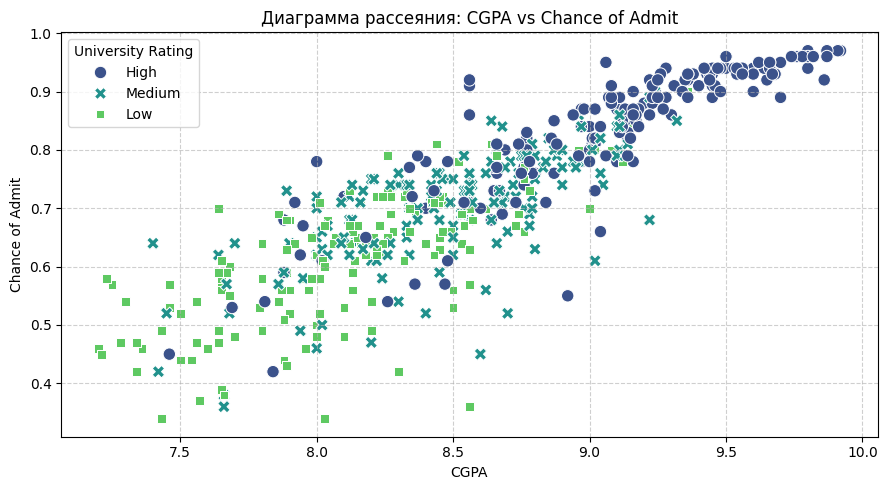

In [7]:
# Диаграмма рассеяния: CGPA vs Chance of Admit
# (дополнительное требование для группы ИУ5-61Б)
plt.figure(figsize=(9, 5))
sns.scatterplot(
    data=df,
    x='CGPA',
    y='Chance of Admit ',
    hue='Univ_Category',
    style='Univ_Category',
    palette='viridis',
    s=80
)
plt.title('Диаграмма рассеяния: CGPA vs Chance of Admit')
plt.xlabel('CGPA')
plt.ylabel('Chance of Admit')
plt.legend(title='University Rating')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()